In [2]:
import zipfile, os

# 1) 경로 설정 (본인 환경에 맞게 수정)
ZIP_PATH   = r"C:\대외활동\2026\Oracle Analytics & AI 기반 정책 인사이트 프로젝트\Wallet_CallTaxi.zip"
WALLET_DIR = r"C:\oracle\wallet"     # 경로에 한글/공백 없는 곳 권장

# 2) 압축 해제
os.makedirs(WALLET_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(WALLET_DIR)

print(os.listdir(WALLET_DIR))

['cwallet.sso', 'ewallet.p12', 'ewallet.pem', 'keystore.jks', 'ojdbc.properties', 'README', 'sqlnet.ora', 'tnsnames.ora', 'truststore.jks', 'Wallet_CallTaxi.zip']


In [3]:
import oracledb, getpass

WALLET_DIR = r"C:\oracle\wallet"

conn = oracledb.connect(
    user="ADMIN",
    password="Calltaxi2026!",
    dsn="calltaxi_high",                    # ③에서 확인한 이름
    config_dir=WALLET_DIR,
    wallet_location=WALLET_DIR,
    wallet_password="Calltaxi2026!",
)

In [4]:
import pandas as pd

df = pd.read_sql("""
    SELECT table_name, num_rows
    FROM user_tables
    ORDER BY table_name
""", conn)
print(df)

C:\Users\seoye\AppData\Local\Temp\ipykernel_306076\1229118901.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


                  TABLE_NAME  NUM_ROWS
0              CALLTAXI_2025   1488498
1           CALLTAXI_BEST100     20400
2     CALLTAXI_BOARDING_2025   1729476
3             CALLTAXI_DAILY       203
4               CITY_PARKING       122
5  DBTOOLS$EXECUTION_HISTORY         2
6             PUBLIC_PARKING      2189


In [5]:
df1 = pd.read_sql("SELECT * FROM CITY_PARKING", conn)
print(df1.shape)
print(df1.head())

C:\Users\seoye\AppData\Local\Temp\ipykernel_306076\2293651118.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql("SELECT * FROM CITY_PARKING", conn)


(122, 42)
  PKLT_CD          PKLT_NM            ADDR PKLT_TYPE PRK_TYPE_NM OPER_SE  \
0  171721     세종로 공영주차장(시)    종로구 세종로 80-1        NW      노외 주차장       1   
1  171730   종묘주차장 공영주차장(시)     종로구 훈정동 2-0        NW      노외 주차장       1   
2  171900   훈련원공원 공영주차장(시)   중구 을지로5가 40-3        NW      노외 주차장       1   
3  172051    한강진역 공영주차장(시)  용산구 한남동 728-27        NW      노외 주차장       1   
4  172065  용산주차빌딩 공영주차장(시)  용산구 한강로2가 12-9        NW      노외 주차장       1   

  OPER_SE_NM         TELNO PRK_STTS_YN                    PRK_STTS_NM  ...  \
0    시간제 주차장  02-2290-6566           1  현재~20분이내 연계데이터 존재(현재 주차대수 표현)  ...   
1    시간제 주차장  02-2290-6166           1  현재~20분이내 연계데이터 존재(현재 주차대수 표현)  ...   
2    시간제 주차장  02-3405-4597           1  현재~20분이내 연계데이터 존재(현재 주차대수 표현)  ...   
3    시간제 주차장   02-795-6406           1  현재~20분이내 연계데이터 존재(현재 주차대수 표현)  ...   
4    시간제 주차장  02-2290-6014           1  현재~20분이내 연계데이터 존재(현재 주차대수 표현)  ...   

  ADD_PRK_HR BUS_BSC_PRK_CRG BUS_BSC_PRK_HR BUS_ADD_PRK_HR BUS_A

In [6]:
df1.columns.tolist()

['PKLT_CD',
 'PKLT_NM',
 'ADDR',
 'PKLT_TYPE',
 'PRK_TYPE_NM',
 'OPER_SE',
 'OPER_SE_NM',
 'TELNO',
 'PRK_STTS_YN',
 'PRK_STTS_NM',
 'TPKCT',
 'NOW_PRK_VHCL_CNT',
 'NOW_PRK_VHCL_UPDT_TM',
 'PAY_YN',
 'PAY_YN_NM',
 'NGHT_PAY_YN',
 'NGHT_PAY_YN_NM',
 'WD_OPER_BGNG_TM',
 'WD_OPER_END_TM',
 'WE_OPER_BGNG_TM',
 'WE_OPER_END_TM',
 'LHLDY_OPER_BGNG_TM',
 'LHLDY_OPER_END_TM',
 'SAT_CHGD_FREE_SE',
 'SAT_CHGD_FREE_NM',
 'LHLDY_CHGD_FREE_SE',
 'LHLDY_CHGD_FREE_SE_NAME',
 'PRD_AMT',
 'STRT_PKLT_MNG_NO',
 'BSC_PRK_CRG',
 'BSC_PRK_HR',
 'ADD_PRK_CRG',
 'ADD_PRK_HR',
 'BUS_BSC_PRK_CRG',
 'BUS_BSC_PRK_HR',
 'BUS_ADD_PRK_HR',
 'BUS_ADD_PRK_CRG',
 'DAY_MAX_CRG',
 'SHRN_PKLT_MNG_NM',
 'SHRN_PKLT_MNG_URL',
 'SHRN_PKLT_YN',
 'SHRN_PKLT_ETC']

In [7]:
df2 = pd.read_sql("SELECT * FROM PUBLIC_PARKING", conn)
print(df2.head())

C:\Users\seoye\AppData\Local\Temp\ipykernel_306076\3315067016.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql("SELECT * FROM PUBLIC_PARKING", conn)


         PKLT_NM           ADDR  PKLT_CD PKLT_KND PKLT_KND_NM OPER_SE  \
0  여의서로 공영주차장(시)  영등포구 여의도동 8-1  1563914       NS      노상 주차장       1   
1  여의서로 공영주차장(시)  영등포구 여의도동 8-1  1563914       NS      노상 주차장       1   
2  여의서로 공영주차장(시)  영등포구 여의도동 8-1  1563914       NS      노상 주차장       1   
3  여의서로 공영주차장(시)  영등포구 여의도동 8-1  1563914       NS      노상 주차장       1   
4  여의서로 공영주차장(시)  영등포구 여의도동 8-1  1563914       NS      노상 주차장       1   

  OPER_SE_NM TELNO PRK_NOW_INFO_PVSN_YN        PRK_NOW_INFO_PVSN_YN_NM  ...  \
0    시간제 주차장  None                    1  현재~20분이내 연계데이터 존재(현재 주차대수 표현)  ...   
1    시간제 주차장  None                    1  현재~20분이내 연계데이터 존재(현재 주차대수 표현)  ...   
2    시간제 주차장  None                    1  현재~20분이내 연계데이터 존재(현재 주차대수 표현)  ...   
3    시간제 주차장  None                    1  현재~20분이내 연계데이터 존재(현재 주차대수 표현)  ...   
4    시간제 주차장  None                    1  현재~20분이내 연계데이터 존재(현재 주차대수 표현)  ...   

  ADD_CRG ADD_UNIT_TM_MNT BUS_PRK_CRG BUS_PRK_HM BUS_PRK_ADD_HM  \
0     280          

In [8]:
df2.columns.tolist()

['PKLT_NM',
 'ADDR',
 'PKLT_CD',
 'PKLT_KND',
 'PKLT_KND_NM',
 'OPER_SE',
 'OPER_SE_NM',
 'TELNO',
 'PRK_NOW_INFO_PVSN_YN',
 'PRK_NOW_INFO_PVSN_YN_NM',
 'TPKCT',
 'CHGD_FREE_SE',
 'CHGD_FREE_NM',
 'NGHT_FREE_OPN_YN',
 'NGHT_FREE_OPN_YN_NAME',
 'WD_OPER_BGNG_TM',
 'WD_OPER_END_TM',
 'WE_OPER_BGNG_TM',
 'WE_OPER_END_TM',
 'LHLDY_BGNG',
 'LHLDY',
 'LAST_DATA_SYNC_TM',
 'SAT_CHGD_FREE_SE',
 'SAT_CHGD_FREE_NM',
 'LHLDY_YN',
 'LHLDY_NM',
 'MNTL_CMUT_CRG',
 'CRB_PKLT_MNG_GROUP_NO',
 'PRK_CRG',
 'PRK_HM',
 'ADD_CRG',
 'ADD_UNIT_TM_MNT',
 'BUS_PRK_CRG',
 'BUS_PRK_HM',
 'BUS_PRK_ADD_HM',
 'BUS_PRK_ADD_CRG',
 'DLY_MAX_CRG',
 'LAT',
 'LOT',
 '시영여부']

In [9]:
import pandas as pd

city   = pd.read_sql("SELECT * FROM CITY_PARKING", conn)
public = pd.read_sql("SELECT * FROM PUBLIC_PARKING", conn)

# 공통 스키마로 컬럼명 통일
city_map = {
    'PKLT_CD':'주차장코드','PKLT_NM':'주차장명','ADDR':'주소',
    'PRK_TYPE_NM':'종류명','OPER_SE_NM':'운영구분명','TELNO':'전화',
    'TPKCT':'총주차면수','PAY_YN_NM':'유무료','NGHT_PAY_YN_NM':'야간무료',
    'WD_OPER_BGNG_TM':'평일시작','WD_OPER_END_TM':'평일종료',
    'WE_OPER_BGNG_TM':'주말시작','WE_OPER_END_TM':'주말종료',
    'PRD_AMT':'정기권요금','BSC_PRK_CRG':'기본요금','BSC_PRK_HR':'기본시간',
    'ADD_PRK_CRG':'추가요금','ADD_PRK_HR':'추가시간','DAY_MAX_CRG':'일최대요금',
    'NOW_PRK_VHCL_CNT':'현재주차수','NOW_PRK_VHCL_UPDT_TM':'갱신시각',
}
public_map = {
    'PKLT_CD':'주차장코드','PKLT_NM':'주차장명','ADDR':'주소',
    'PKLT_KND_NM':'종류명','OPER_SE_NM':'운영구분명','TELNO':'전화',
    'TPKCT':'총주차면수','CHGD_FREE_NM':'유무료','NGHT_FREE_OPN_YN_NAME':'야간무료',
    'WD_OPER_BGNG_TM':'평일시작','WD_OPER_END_TM':'평일종료',
    'WE_OPER_BGNG_TM':'주말시작','WE_OPER_END_TM':'주말종료',
    'MNTL_CMUT_CRG':'정기권요금','PRK_CRG':'기본요금','PRK_HM':'기본시간',
    'ADD_CRG':'추가요금','ADD_UNIT_TM_MNT':'추가시간','DLY_MAX_CRG':'일최대요금',
    'LAST_DATA_SYNC_TM':'갱신시각','LAT':'위도','LOT':'경도',
}

city_std   = city.rename(columns=city_map)[list(city_map.values())].copy()
public_std = public.rename(columns=public_map)[list(public_map.values())].copy()

city_std['출처']   = 'CITY'
public_std['출처'] = 'PUBLIC'

df = pd.concat([city_std, public_std], ignore_index=True)  # 없는 컬럼은 자동 NaN
print(df.shape)
df.head()


C:\Users\seoye\AppData\Local\Temp\ipykernel_306076\1205041225.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  city   = pd.read_sql("SELECT * FROM CITY_PARKING", conn)
C:\Users\seoye\AppData\Local\Temp\ipykernel_306076\1205041225.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  public = pd.read_sql("SELECT * FROM PUBLIC_PARKING", conn)


(2311, 24)


,주차장코드,주차장명,주소,종류명,운영구분명,전화,총주차면수,유무료,야간무료,평일시작,...,기본요금,기본시간,추가요금,추가시간,일최대요금,현재주차수,갱신시각,출처,위도,경도
0,171721,세종로 공영주차장(시),종로구 세종로 80-1,노외 주차장,시간제 주차장,02-2290-6566,1260,유료,야간 미개방,0,...,430,5,430,5,0,670,2026-07-24 12:48:53,CITY,NaN,NaN
1,171730,종묘주차장 공영주차장(시),종로구 훈정동 2-0,노외 주차장,시간제 주차장,02-2290-6166,1312,유료,야간 미개방,0,...,400,5,400,5,0,1261,2026-07-24 12:48:53,CITY,NaN,NaN
2,171900,훈련원공원 공영주차장(시),중구 을지로5가 40-3,노외 주차장,시간제 주차장,02-3405-4597,873,유료,야간 미개방,0,...,550,5,550,5,0,687,2026-07-24 12:48:54,CITY,NaN,NaN
3,172051,한강진역 공영주차장(시),용산구 한남동 728-27,노외 주차장,시간제 주차장,02-795-6406,174,유료,야간 미개방,0,...,400,5,400,5,0,156,2026-07-24 12:48:53,CITY,NaN,NaN
4,172065,용산주차빌딩 공영주차장(시),용산구 한강로2가 12-9,노외 주차장,시간제 주차장,02-2290-6014,559,유료,야간 미개방,0,...,270,5,270,5,0,214,2026-07-24 12:48:53,CITY,NaN,NaN


In [10]:
df.duplicated(subset=['주차장코드']).sum()

1456

In [ ]:
# 1) 중복 코드가 어느 출처에서 오는지
dup_codes = df[df.duplicated(subset=['주차장코드'], keep=False)]  # 겹치는 행 전부
print("중복에 얽힌 행 수:", len(dup_codes))
print(dup_codes['출처'].value_counts())

# 2) 특정 중복 코드 하나를 눈으로 확인
sample = dup_codes['주차장코드'].iloc[0]
df[df['주차장코드'] == sample][['주차장코드','주차장명','주소','출처','총주차면수']]

# 3) '같은 코드가 CITY와 PUBLIC 양쪽에 다 있는' 경우가 몇 개인지
cross = df.groupby('주차장코드')['출처'].nunique()
print("양쪽 테이블에 다 있는 코드 수:", (cross > 1).sum())


중복에 얽힌 행 수: 1573
출처
PUBLIC    1456
CITY       117
Name: count, dtype: int64
양쪽 테이블에 다 있는 코드 수: 117


In [12]:
# 1) 코드별 PUBLIC 등장 횟수 상위
pub = df[df['출처']=='PUBLIC']
print(pub['주차장코드'].value_counts().head(10))

# 2) 가장 많이 중복된 코드 하나를 열어보기
top = pub['주차장코드'].value_counts().index[0]
df[(df['주차장코드']==top)][['주차장코드','주차장명','주소','총주차면수','기본요금','출처']]

# 3) 혹시 코드가 비어있어서 뭉친 건지
print("PUBLIC 코드 결측:", pub['주차장코드'].isna().sum())
print("PUBLIC 코드 공백/0 여부:", (pub['주차장코드'].astype(str).str.strip().isin(['','0','None'])).sum())


주차장코드
1563914    84
1367804    81
1540689    72
1163833    59
1915194    48
1576347    48
1477337    47
1576208    41
1451364    39
1585237    38
Name: count, dtype: int64
PUBLIC 코드 결측: 0
PUBLIC 코드 공백/0 여부: 0


In [19]:
import pandas as pd

# PUBLIC의 코드→좌표 사전
coord = (df[df['출처']=='PUBLIC']
           .dropna(subset=['위도','경도'])
           .drop_duplicates('주차장코드')[['주차장코드','위도','경도']])

# CITY에 코드로 좌표 붙이기
city = df[df['출처']=='CITY'].drop(columns=['위도','경도'], errors='ignore')
city = city.merge(coord, on='주차장코드', how='left')
print("좌표 채워진 CITY:", city[['위도','경도']].notna().all(axis=1).sum(), "/", len(city))


좌표 채워진 CITY: 117 / 122


In [21]:
import requests, time

KAKAO_KEY = "51d02db8b40ec9236e81d2d0eb1c83db"

def geocode_kakao(addr):
    if not isinstance(addr, str) or not addr.strip():
        return (None, None)
    url = "https://dapi.kakao.com/v2/local/search/address.json"
    try:
        r = requests.get(url, headers={"Authorization": f"KakaoAK {KAKAO_KEY}"},
                         params={"query": addr}, timeout=5)
        docs = r.json().get("documents", [])
        if docs:
            return (float(docs[0]["y"]), float(docs[0]["x"]))  # y=위도, x=경도
    except Exception as e:
        print("실패:", addr, e)
    return (None, None)

# 아직 좌표 없는 CITY만 지오코딩 (중복 호출 방지)
mask = city[['위도','경도']].isna().any(axis=1)
todo = city.loc[mask, '주소'].dropna().unique()
print("지오코딩할 주소 수:", len(todo))

cache = {}
for i, a in enumerate(todo):
    cache[a] = geocode_kakao(a)
    time.sleep(0.05)                       # 호출 간격 (초당 과다호출 방지)
    if i % 20 == 0: print(f"{i}/{len(todo)}")

# 캐시로 채우기
city.loc[mask, '위도'] = city.loc[mask, '주소'].map(lambda a: cache.get(a, (None,None))[0])
city.loc[mask, '경도'] = city.loc[mask, '주소'].map(lambda a: cache.get(a, (None,None))[1])
print("최종 좌표 채워진 CITY:", city[['위도','경도']].notna().all(axis=1).sum(), "/", len(city))


지오코딩할 주소 수: 5
0/5
최종 좌표 채워진 CITY: 117 / 122


In [22]:
# 1) 실패한 5개 주소가 뭔지 보기
mask = city[['위도','경도']].isna().any(axis=1)
print(city.loc[mask, ['주차장명','주소']])

# 2) 그 중 하나로 API 응답 직접 확인 (상태코드/본문)
import requests
addr = city.loc[mask, '주소'].dropna().iloc[0]
r = requests.get("https://dapi.kakao.com/v2/local/search/address.json",
                 headers={"Authorization": f"KakaoAK {KAKAO_KEY}"},
                 params={"query": addr})
print("status:", r.status_code)
print(r.json())


                       주차장명              주소
2            훈련원공원 공영주차장(시)   중구 을지로5가 40-3
3             한강진역 공영주차장(시)  용산구 한남동 728-27
46           해군본부앞 공영주차장(시)  영등포구 신길동 812-0
104           학여울역 공영주차장(시)   강남구 대치동 514-1
116  훈련원공원 앞 관광버스 전용 주차장(시)  중구 을지로5가 40-2 
status: 403
{'errorType': 'NotAuthorizedError', 'message': 'App(콜밸런스) disabled OPEN_MAP_AND_LOCAL service.'}


In [23]:
manual_by_name = {
    '훈련원공원 공영주차장(시)':          (37.5670765, 127.0034106),
    '한강진역 공영주차장(시)':            (37.5395059, 127.0025562),
    '해군본부앞 공영주차장(시)':          (37.5044025, 126.9209768),
    '학여울역 공영주차장(시)':            (37.4970066, 127.0723618),
    '훈련원공원 앞 관광버스 전용 주차장(시)': (37.5670765, 127.0034106),
}
for idx in city[mask].index:
    nm = str(city.loc[idx, '주차장명']).strip()
    if nm in manual_by_name:
        city.loc[idx, '위도'], city.loc[idx, '경도'] = manual_by_name[nm]

print("최종:", city[['위도','경도']].notna().all(axis=1).sum(), "/", len(city))


최종: 122 / 122


In [25]:
import folium
import pandas as pd

pub = df[df['출처']=='PUBLIC'].copy()

# 합치기
allp = pd.concat([pub, city], ignore_index=True)

# ★ 합친 뒤에 숫자 변환 (이 줄이 핵심)
allp['위도'] = pd.to_numeric(allp['위도'], errors='coerce')
allp['경도'] = pd.to_numeric(allp['경도'], errors='coerce')

# 좌표 있는 것만 + 서울 범위만
allp = allp.dropna(subset=['위도','경도'])
allp = allp[allp['위도'].between(37.0, 37.9) & allp['경도'].between(126.5, 127.3)]

print("총 마커:", len(allp))
print(allp['출처'].value_counts())

# 지도
m = folium.Map(location=[37.5665, 126.9780], zoom_start=11)
color = {'PUBLIC': 'crimson', 'CITY': 'royalblue'}
for _, r in allp.iterrows():
    folium.CircleMarker(
        location=[r['위도'], r['경도']],
        radius=2, color=color.get(r['출처'], 'gray'),
        fill=True, fill_opacity=0.6,
        popup=f"[{r['출처']}] {r['주차장명']}",
    ).add_to(m)

m.save("parking_map.html")
m


총 마커: 1578
출처
PUBLIC    1456
CITY       122
Name: count, dtype: int64


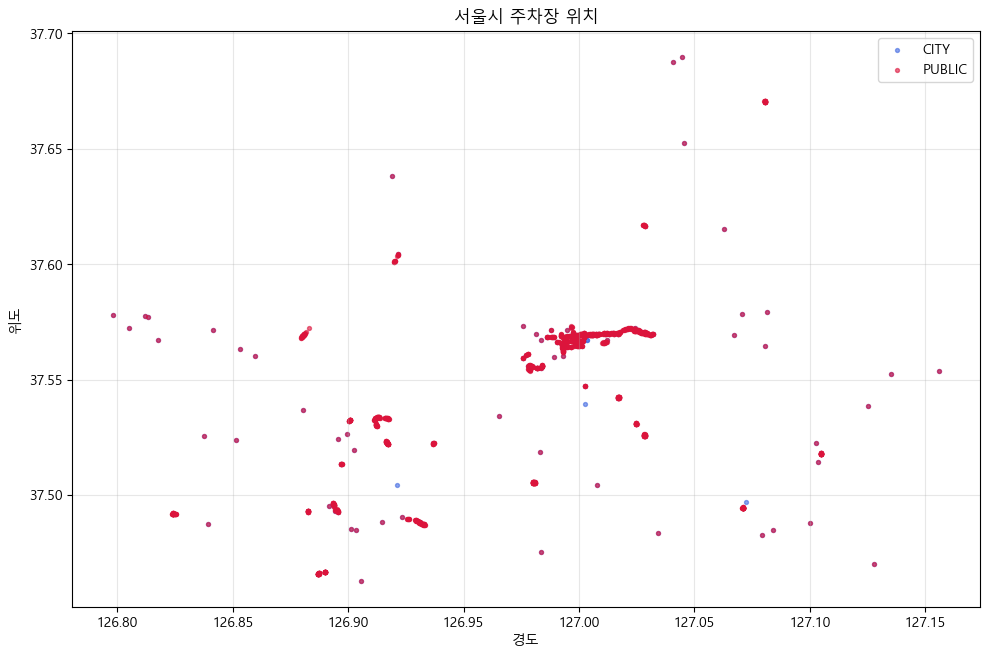

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 (윈도우)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 좌표 숫자화 + 유효값만 (allp 이미 있으면 이 4줄은 생략 가능)
plot_df = pd.concat([df[df['출처']=='PUBLIC'], city], ignore_index=True)
plot_df['위도'] = pd.to_numeric(plot_df['위도'], errors='coerce')
plot_df['경도'] = pd.to_numeric(plot_df['경도'], errors='coerce')
plot_df = plot_df.dropna(subset=['위도','경도'])
plot_df = plot_df[plot_df['위도'].between(37.0,37.9) & plot_df['경도'].between(126.5,127.3)]

fig, ax = plt.subplots(figsize=(10, 9))
color = {'PUBLIC': 'crimson', 'CITY': 'royalblue'}
for src, g in plot_df.groupby('출처'):
    ax.scatter(g['경도'], g['위도'], s=8, alpha=0.6,
               c=color.get(src, 'gray'), label=src)

ax.set_xlabel('경도'); ax.set_ylabel('위도')
ax.set_title('서울시 주차장 위치')
ax.set_aspect('equal')      # 위경도 왜곡 방지 → 지도 모양 유지
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


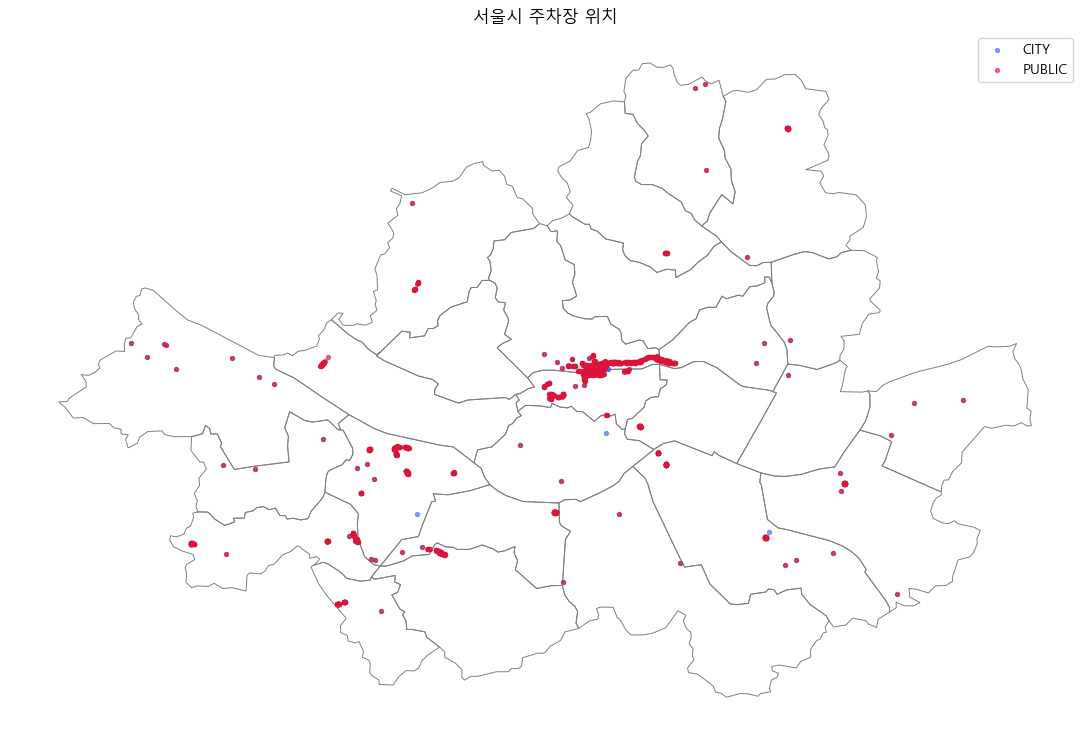

In [27]:
import requests, json
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1) 서울 자치구 경계 GeoJSON 다운로드
url = "https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json"
geo = requests.get(url).json()

# 2) 좌표 데이터 준비
plot_df = pd.concat([df[df['출처']=='PUBLIC'], city], ignore_index=True)
plot_df['위도'] = pd.to_numeric(plot_df['위도'], errors='coerce')
plot_df['경도'] = pd.to_numeric(plot_df['경도'], errors='coerce')
plot_df = plot_df.dropna(subset=['위도','경도'])
plot_df = plot_df[plot_df['위도'].between(37.0,37.9) & plot_df['경도'].between(126.5,127.3)]

# 3) 그리기
fig, ax = plt.subplots(figsize=(11, 10))

# 자치구 경계선
def draw_ring(ax, coords):
    xs = [c[0] for c in coords]; ys = [c[1] for c in coords]
    ax.plot(xs, ys, color='gray', linewidth=0.7)

for feat in geo['features']:
    geom = feat['geometry']
    if geom['type'] == 'Polygon':
        for ring in geom['coordinates']:
            draw_ring(ax, ring)
    elif geom['type'] == 'MultiPolygon':
        for poly in geom['coordinates']:
            for ring in poly:
                draw_ring(ax, ring)

# 주차장 점
color = {'PUBLIC':'crimson', 'CITY':'royalblue'}
for src, g in plot_df.groupby('출처'):
    ax.scatter(g['경도'], g['위도'], s=8, alpha=0.6,
               c=color.get(src,'gray'), label=src, zorder=3)

ax.set_aspect('equal')
ax.set_title('서울시 주차장 위치')
ax.set_xlabel('경도'); ax.set_ylabel('위도')
ax.legend()
ax.axis('off')          # 축 숨겨서 지도처럼 깔끔하게 (원하면 삭제)
plt.tight_layout()
plt.show()
